In [ ]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, FIGURES_DIR, MOUSE_IDS_DUAL

from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pynapple as nap

states = ['wake', 'nrem', 'rem']

### Load CW turn cells

In [6]:
mouse_id = MOUSE_IDS_DUAL[0]
sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
cw_units = turn_units[turn_units['is_cw']]
cw_units

  Index      rate    turn_index  is_cw
-------  --------  ------------  -------
     12   4.3682           1.65  True
     15  10.081            0.55  True
     18  38.9742           0.1   True
     19   8.31619          0.17  True
     81  25.7898           0.29  True
     83   0.56943          0.68  True
     88   0.19866          0.36  True
     90   8.84353          0.09  True
    148  11.6266           0.17  True

### Detecting population events

In [82]:
bin_ms = 1
p = cw_units.count(bin_size=bin_ms, time_units='ms')
p = p.sum(axis=1) * 1000 /bin_ms
p = p.smooth(std=50, time_units='ms')
p

Time (s)
--------------------  -------
0.00655               55.3514
0.007549999999999999  56.1405
0.00855               56.926
0.009550000000000001  57.7076
0.01055               58.4849
0.011550000000000001  59.2576
0.01255               60.0254
...
40919.84055           37.6069
40919.841550000005    37.0875
40919.84255           36.5676
40919.843550000005    36.0474
40919.84455           35.527
40919.845550000005    35.0066
40919.84655           34.4863
dtype: float64, shape: (40919841,)

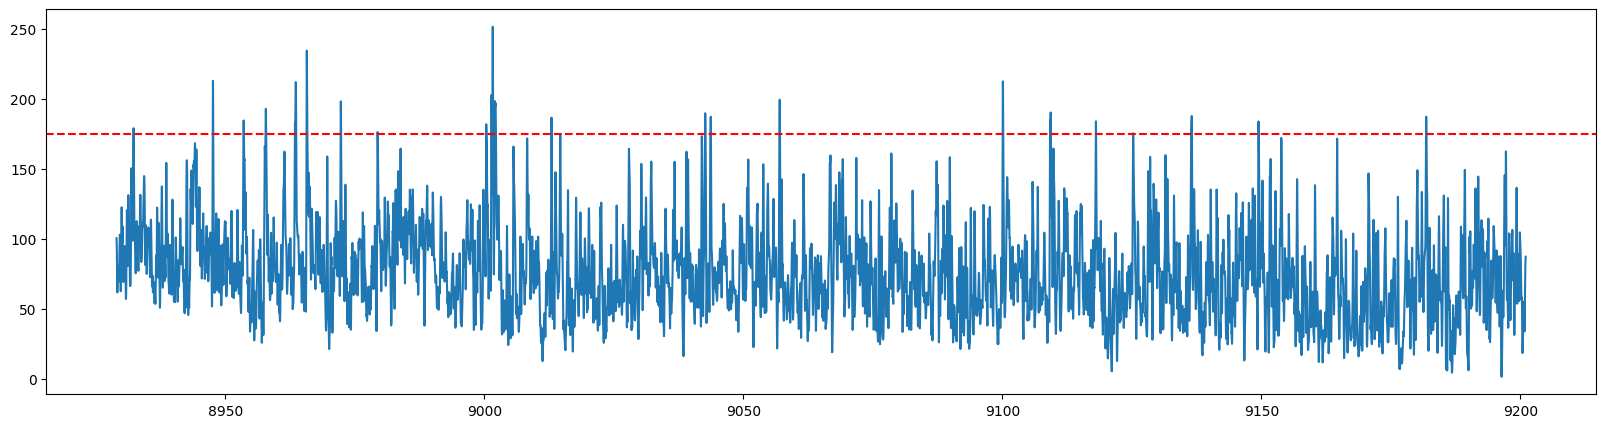

In [99]:
threshold = 1 * p.std() + p.mean()
plt.figure(figsize=(20, 5))
plt.plot(p.restrict(sleep[sleep['state'] == 'nrem'][7]))
plt.axhline(threshold, color='r', linestyle='--')

In [117]:
all_population_events = {'wake': [], 'nrem': [], 'rem': []}
for state in states:
    p_state = p.restrict(sleep[sleep['state'] == state])
    thr = 1 * p_state.std() + p_state.mean()
    all_population_events[state] = p_state.threshold(thr).time_support

    print(f"{state}: {p_state.mean():.3f} ± {p_state.std():.3f}")
    print(f"population event threshold: {thr:.3f}")


wake: 124.319 ± 68.469
population event threshold: 192.787
nrem: 70.647 ± 39.802
population event threshold: 110.449
rem: 129.097 ± 75.540
population event threshold: 204.638


In [217]:
rates = {}

for uid in cw_units:
    result = {}
    for state, population_events in all_population_events.items():
        duration = population_events['end'] - population_events['start']
        t = cw_units[uid].restrict(population_events).t
        
        # alternative to looping over events
        left = np.searchsorted(t, population_events['start'], side='left')
        right = np.searchsorted(t, population_events['end'], side='right')
        count = right - left
        
        rate_by_event = count / duration
        result[state] = rate_by_event.mean()
    rates[uid] = result
rates = pd.DataFrame(rates).T
rates

,wake,nrem,rem
12,9.214580,14.493317,27.551943
15,17.508076,15.784197,15.145891
18,69.045946,48.048500,73.864778
19,24.213814,3.086723,5.530131
81,67.530959,51.041970,106.219487
83,2.936445,0.283309,2.142375
88,0.221569,0.352175,0.613427
90,18.924665,7.732102,12.839505
148,26.097584,8.361137,17.990728


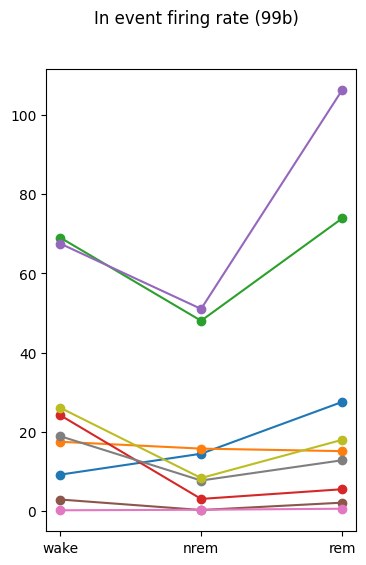

In [218]:
fig, ax = plt.subplots(figsize=(4, 6))
fig.suptitle(f"In event firing rate ({mouse_id})")
for _, unit_rates in rates.iterrows():
    ax.plot(states, unit_rates, marker='o')

In [222]:
result = {}
for state, population_events in all_population_events.items():
    duration = population_events['end'] - population_events['start']
    result[state] = duration.mean()
result

{'wake': np.float64(0.36341769903836707),
 'nrem': np.float64(0.2004070982464592),
 'rem': np.float64(0.2732640653358445)}

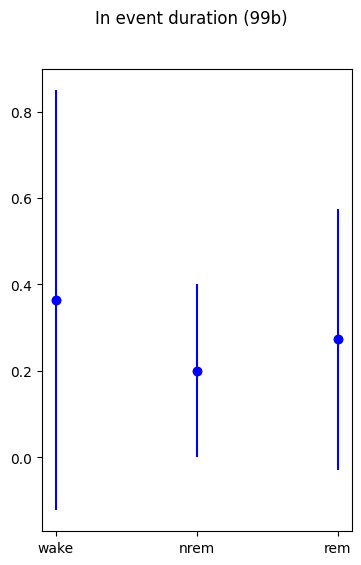

In [223]:
fig, ax = plt.subplots(figsize=(4, 6))
fig.suptitle(f"In event duration ({mouse_id})")
for state, population_events in all_population_events.items():
    duration = population_events['end'] - population_events['start']
    ax.plot(state, duration.mean(), marker='o')
    ax.errorbar(state, duration.mean(), yerr=duration.std(), fmt='o', color='b')